# 📌 NOTE CHỤP HÌNH CHO BÁO CÁO
Các ghi chú có biểu tượng **📸 CHÈN HÌNH BÁO CÁO** đã được đặt trực tiếp ngay trên cell cần chụp. Dùng `Ctrl+F` và tìm cụm **CHÈN HÌNH BÁO CÁO** để nhảy nhanh giữa các vị trí.


# Linear Regression - From Scratch và `scikit-learn`


## Lý thuyết Linear Regression

**Linear Regression (Hồi quy tuyến tính)** là thuật toán học máy giám sát dùng để dự đoán kết quả dạng số liên tục dựa trên các biến độc lập. Cụ thể:

### 1. Ý tưởng cốt lõi
* Tìm mối quan hệ **tuyến tính** giữa biến độc lập (features) $X$ và biến phụ thuộc (target) $y$.
* Phương trình giả định: $\hat{y} = Xw + b$ (với $w$ là weights/trọng số và $b$ là bias).
* Mục tiêu là tìm bộ tham số $(w, b)$ làm giảm tối đa hàm mất mát Mean Squared Error (MSE):
  $$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

### 2. Các bước thực hiện

* **Bước 1 (Khởi tạo):** Khởi tạo weights $w = 0$ và bias $b = 0$.
* **Bước 2 (Forward pass):** Tính dự đoán $\hat{y} = Xw + b$.
* **Bước 3 (Tính gradient):** Tính đạo hàm MSE theo $w$ và $b$:
  * $\frac{\partial MSE}{\partial w} = \frac{2}{N} X^T (\hat{y} - y)$
  * $\frac{\partial MSE}{\partial b} = \frac{2}{N} \sum (\hat{y} - y)$
* **Bước 4 (Cập nhật tham số):** Gradient Descent với learning rate $\alpha$:
  * $w \leftarrow w - \alpha \frac{\partial MSE}{\partial w}$
  * $b \leftarrow b - \alpha \frac{\partial MSE}{\partial b}$
* **Bước 5 (Lặp lại):** Lặp lại bước 2–4 cho đến khi hội tụ hoặc đủ số epoch.

### 3. Ưu điểm so với các phương pháp phức tạp hơn
* **Đơn giản, dễ giải thích** — hệ số $w$ phản ánh trực tiếp ảnh hưởng của từng feature.
* **Tốc độ nhanh** — giải tích bằng Normal Equation (OLS) cho nghiệm tối ưu tức thì: $w = (X^T X)^{-1} X^T y$.
* **Nền tảng** cho các mô hình phức tạp hơn như Ridge, Lasso, Elastic Net.


## Triển khai `LinearRegression` không dùng thư viện


### Import thư viện và load dữ liệu


In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn.linear_model
import os, sys, time

sys.path.insert(0, os.path.abspath('.'))
from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from pathlib import Path

# Tìm thư mục gốc của Practice 2 để import utils và đọc data bằng đường dẫn tương đối.
PROJECT_ROOT = Path.cwd().resolve()
if not ((PROJECT_ROOT / 'utils').exists() and (PROJECT_ROOT / 'data').exists()):
    for candidate in PROJECT_ROOT.parents:
        if (candidate / 'utils').exists() and (candidate / 'data').exists():
            PROJECT_ROOT = candidate
            break
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from utils.model_manager import save_model_package


In [2]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test  = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train_log.pkl')
y_test  = joblib.load('./data/ready_for_train/y_test_log.pkl')

print('Training dataset shape:')
print(f'X: {X_train.shape}')
print(f'y: {y_train.shape}')

print('Testing dataset shape:')
print(f'X: {X_test.shape}')
print(f'y: {y_test.shape}')

Training dataset shape:
X: (800, 11)
y: (800,)
Testing dataset shape:
X: (200, 11)
y: (200,)


### Triển khai Linear Regression không dùng `sklearn`


---
> 📸 **HÌNH 24 — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-01] — Mục 5.2.1 – Linear Regression From Scratch**  
> Chụp phần class bên dưới, ưu tiên hàm fit(): dự đoán, tính dw/db và cập nhật weights/bias.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [ ]:
class LinearRegressionScratch:
    """Mô hình Linear Regression tự triển khai sử dụng Gradient Descent."""

    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
        self.learning_rate = learning_rate
        self.epochs        = epochs
        self.weights       = None
        self.bias          = None
        self.loss_history  = []

    def get_params(self, deep=True):
        return {'learning_rate': self.learning_rate, 'epochs': self.epochs}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        # Step 1: Initialize weights = 0, bias = 0
        self.weights      = np.zeros(n_features)
        self.bias         = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            # Step 2: Forward pass
            y_pred = np.dot(X, self.weights) + self.bias

            # Step 3: Computing Gradient
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Bước 4: Update Weights and Bias (Gradient Descent)
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            # Bước 5: Append Loss History
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X) -> np.ndarray:
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

### Kiểm tra nhanh mô hình Linear Regression From Scratch


In [4]:
y_train_original = np.expm1(y_train)
y_test_original  = np.expm1(y_test)

quick_lr = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

start = time.time()
quick_lr.fit(X_train, y_train.values)
train_time = time.time() - start

In [5]:
quick_pred = np.expm1(quick_lr.predict(X_test))

---
> 📸 **HÌNH 22 — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-02] — Mục 5.1 – Baseline Model**  
> Chụp cell code và output R², RMSE, MAE, MAPE của mô hình Linear Regression chạy nhanh trước tuning.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [6]:
r2   = r2_score(y_test_original, quick_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, quick_pred))
mae  = mean_absolute_error(y_test_original, quick_pred)
mape = mean_absolute_percentage_error(y_test_original, quick_pred) * 100 # Nhân 100 để lấy định dạng %

print(f'Quick test (1000 epochs) - Train time: {train_time:.1f}s')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f"MAPE : {mape:.2f} %")

Quick test (1000 epochs) - Train time: 0.0s
R²   : 0.5663
RMSE : 356.32
MAE  : 211.38
MAPE : 58.48 %


---
> 📸 **HÌNH 23 — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-03] — Mục 5.1 – Learning Curve**  
> Chụp biểu đồ output ngay dưới cell này để minh họa loss giảm theo epoch.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

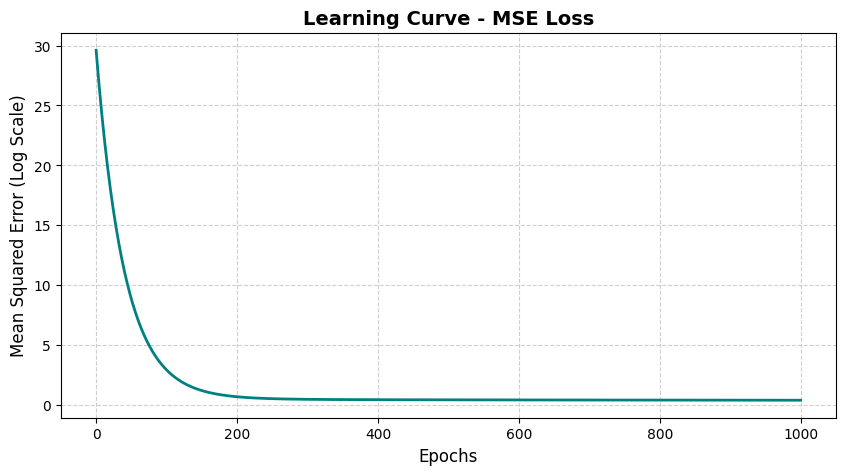

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(quick_lr.epochs), quick_lr.loss_history, color='teal', linewidth=2)
plt.title('Learning Curve - MSE Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Dùng thư viện `sklearn` để triển khai `LinearRegression`


In [8]:
sklearn_lr = LinearRegression()

start = time.time()
sklearn_lr.fit(X_train, y_train)
train_time_sklearn = time.time() - start

sklearn_pred = np.expm1(sklearn_lr.predict(X_test))

r2_sk   = r2_score(y_test_original, sklearn_pred)
rmse_sk = np.sqrt(mean_squared_error(y_test_original, sklearn_pred))
mae_sk  = mean_absolute_error(y_test_original, sklearn_pred)
mape_sk = mean_absolute_percentage_error(y_test_original, sklearn_pred) * 100
print(f'sklearn LinearRegression - Train time: {train_time_sklearn:.1f}s')
print(f'R²   : {r2_sk:.4f}')
print(f'RMSE : {rmse_sk:.2f}')
print(f'MAE  : {mae_sk:.2f}')
print(f"MAPE : {mape_sk:.2f} %")

sklearn LinearRegression - Train time: 0.0s
R²   : 0.6075
RMSE : 338.95
MAE  : 202.57
MAPE : 56.02 %


---
> 📸 **HÌNH 25A (TÙY CHỌN) — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-04] — Mục 5.3 – Hyperparameter Grid của Linear Regression**  
> Chụp cell code ngay bên dưới để trình bày không gian siêu tham số learning_rate và epochs.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

## Hyperparameter Tuning

Để tối ưu hóa Linear Regression, Grid Search kết hợp với **5-fold Cross Validation** được sử dụng nhằm tìm ra bộ hyperparameters phù hợp nhất.

Parameter grid được sử dụng:

```python
lr_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'epochs'       : [500, 1000, 2000],
}
```

Trong đó:
* `learning_rate` — tốc độ học của Gradient Descent.
* `epochs` — số vòng lặp huấn luyện.

Mô hình được đánh giá trên **giá trị gốc** (`Total Amount`) sau khi `inverse transform` qua `np.expm1()`.


---
> 📸 **HÌNH 25A (TÙY CHỌN) — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-05] — Mục 5.3 – Hyperparameter Grid của Linear Regression**  
> Chụp cell code ngay bên dưới để trình bày không gian siêu tham số learning_rate và epochs.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [9]:
lr_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'epochs'       : [500, 1000, 2000],
}

### Grid Search dùng Neg RMSE


In [10]:
cv = CustomKFold(n_splits=5, shuffle=True, random_state=42)
scratch_lr = LinearRegressionScratch()

lr_grid_search = CustomGridSearchCV(
    estimator=scratch_lr,
    param_grid=lr_grid,
    cv=cv,
    scoring='neg_rmse'
)

lr_grid_search.fit(X_train, y_train.values)

Bắt đầu GridSearchCV: 9 tổ hợp tham số, 5 folds.
[1/9] Params: {'learning_rate': 0.001, 'epochs': 500} --> neg_rmse: -2.9922


[2/9] Params: {'learning_rate': 0.001, 'epochs': 1000} --> neg_rmse: -1.7333


[3/9] Params: {'learning_rate': 0.001, 'epochs': 2000} --> neg_rmse: -0.8473
[4/9] Params: {'learning_rate': 0.01, 'epochs': 500} --> neg_rmse: -0.6699
[5/9] Params: {'learning_rate': 0.01, 'epochs': 1000} --> neg_rmse: -0.6465


[6/9] Params: {'learning_rate': 0.01, 'epochs': 2000} --> neg_rmse: -0.6271
[7/9] Params: {'learning_rate': 0.1, 'epochs': 500} --> neg_rmse: -0.6194
[8/9] Params: {'learning_rate': 0.1, 'epochs': 1000} --> neg_rmse: -0.6193


[9/9] Params: {'learning_rate': 0.1, 'epochs': 2000} --> neg_rmse: -0.6193

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'epochs': 1000}
-> Điểm neg_rmse TỐT NHẤT: -0.6193


### Grid Search dùng R²


In [11]:
cv = CustomKFold(n_splits=5, shuffle=True, random_state=42)
scratch_lr = LinearRegressionScratch()

lr_grid_search_r2 = CustomGridSearchCV(
    estimator=scratch_lr,
    param_grid=lr_grid,
    cv=cv,
    scoring='r2'
)

lr_grid_search_r2.fit(X_train, y_train.values)

Bắt đầu GridSearchCV: 9 tổ hợp tham số, 5 folds.
[1/9] Params: {'learning_rate': 0.001, 'epochs': 500} --> r2: -3.9602


[2/9] Params: {'learning_rate': 0.001, 'epochs': 1000} --> r2: -0.6666


[3/9] Params: {'learning_rate': 0.001, 'epochs': 2000} --> r2: 0.6013
[4/9] Params: {'learning_rate': 0.01, 'epochs': 500} --> r2: 0.7516
[5/9] Params: {'learning_rate': 0.01, 'epochs': 1000} --> r2: 0.7688


[6/9] Params: {'learning_rate': 0.01, 'epochs': 2000} --> r2: 0.7825
[7/9] Params: {'learning_rate': 0.1, 'epochs': 500} --> r2: 0.7879


[8/9] Params: {'learning_rate': 0.1, 'epochs': 1000} --> r2: 0.7880


[9/9] Params: {'learning_rate': 0.1, 'epochs': 2000} --> r2: 0.7880

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'epochs': 1000}
-> Điểm r2 TỐT NHẤT: 0.7880


---
> 📸 **HÌNH 25 — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-06] — Mục 5.3 và 6.2 – Kết quả Linear Regression sau tuning**  
> Chụp dòng Best params và bảng/output so sánh From Scratch với sklearn trong cell này.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [12]:
best_params = lr_grid_search_r2.best_params_
print('Best params:', best_params)

# ── From Scratch với best params ──────────────────────
scratch_best = lr_grid_search_r2.best_estimator_

start = time.time()
scratch_best.fit(X_train, y_train.values)
train_time_scratch = time.time() - start

scratch_pred = np.expm1(scratch_best.predict(X_test))

mae_scratch  = mean_absolute_error(y_test_original, scratch_pred)
rmse_scratch = np.sqrt(mean_squared_error(y_test_original, scratch_pred))
r2_scratch   = r2_score(y_test_original, scratch_pred)
mape_scratch = mean_absolute_percentage_error(y_test_original, scratch_pred) * 100

# ── sklearn với cùng cách tiếp cận (train trên y_log) ─ đánh giá trên y_test gốc
start = time.time()
sklearn_best = LinearRegression()
sklearn_best.fit(X_train, y_train)
train_time_sklearn = time.time() - start

sklearn_pred_best = np.expm1(sklearn_best.predict(X_test))

mae_sklearn  = mean_absolute_error(y_test_original, sklearn_pred_best)
rmse_sklearn = np.sqrt(mean_squared_error(y_test_original, sklearn_pred_best))
r2_sklearn   = r2_score(y_test_original, sklearn_pred_best)
mape_sklearn = mean_absolute_percentage_error(y_test_original, sklearn_pred_best) * 100
# ── Bảng so sánh ─────────────────────────────────────
print('\n' + '='*60)
print(f"{'Metric':<15} {'From Scratch':>20} {'sklearn':>20}")
print('='*60)
print(f"{'R²':<15} {r2_scratch:>20.4f} {r2_sklearn:>20.4f}")
print(f"{'RMSE':<15} {rmse_scratch:>20.2f} {rmse_sklearn:>20.2f}")
print(f"{'MAE':<15} {mae_scratch:>20.2f} {mae_sklearn:>20.2f}")
print(f"{'MAPE':<15} {mape_scratch:>20.2f} {mape_sklearn:>20.2f}")
print(f"{'Train Time (s)':<15} {train_time_scratch:>20.1f} {train_time_sklearn:>20.1f}")
print('='*60)

# So sánh sai lệch dự đoán
max_diff = np.max(np.abs(scratch_pred - sklearn_pred_best))
print(f'\nSai lệch dự đoán tối đa giữa 2 mô hình: {max_diff:.4f}')

Best params: {'learning_rate': 0.1, 'epochs': 1000}

Metric                  From Scratch              sklearn
R²                            0.6076               0.6075
RMSE                          338.92               338.95
MAE                           202.51               202.57
MAPE                           56.02                56.02
Train Time (s)                   0.0                  0.0

Sai lệch dự đoán tối đa giữa 2 mô hình: 2.3625


## So sánh y gốc vs y log-transformed

Linear Regression rất nhạy cảm với phân phối của target. Biến mục tiêu (`Total Amount`) có phân phối lệch phải mạnh nên việc áp dụng log-transformation có thể cải thiện đáng kể hiệu năng mô hình.


---
> 📸 **HÌNH 25B (TÙY CHỌN) — CHÈN HÌNH BÁO CÁO [04-TRAIN-LINEAR-REGRESSION-07] — Mục 4.1.2/6.2 – So sánh target gốc và target log**  
> Chụp phần output so sánh y gốc với y log nếu bạn đề cập ảnh hưởng của Log Transform trong báo cáo.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [13]:
import matplotlib.pyplot as plt

# ── From Scratch: y GỐC và y LOG ────────────────────────────────────
sc_orig = LinearRegressionScratch(learning_rate=0.1, epochs=2000)
sc_orig.fit(X_train, y_train_original.values)
pred_sc_orig = sc_orig.predict(X_test)

sc_log = LinearRegressionScratch(learning_rate=0.1, epochs=2000)
sc_log.fit(X_train, y_train.values)
pred_sc_log = np.expm1(sc_log.predict(X_test))

# ── sklearn LinearRegression: y GỐC và y LOG ────────────────────────
sk_orig = LinearRegression()
sk_orig.fit(X_train, y_train_original)
pred_sk_orig = sk_orig.predict(X_test)

sk_log = LinearRegression()
sk_log.fit(X_train, y_train)
pred_sk_log = np.expm1(sk_log.predict(X_test))

# ── Bảng so sánh tổng hợp (đánh giá trên thang đo giá GỐC) ─────────
W = 18
print(f"{'Metric':<15} {'Scratch/y_gốc':>{W}} {'Scratch/y_log':>{W}} {'sklearn/y_gốc':>{W}} {'sklearn/y_log':>{W}}")
print('-' * (15 + W*4 + 3))
for label, pred in [('R²', None), ('RMSE', None), ('MAE', None)]:
    v1 = r2_score(y_test_original, pred_sc_orig)    if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sc_orig)) if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sc_orig))
    v2 = r2_score(y_test_original, pred_sc_log)     if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sc_log))  if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sc_log))
    v3 = r2_score(y_test_original, pred_sk_orig)    if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sk_orig)) if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sk_orig))
    v4 = r2_score(y_test_original, pred_sk_log)     if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sk_log))  if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sk_log))
    fmt = '.4f' if label == 'R²' else '.2f'
    print(f"{label:<15} {v1:>{W}{fmt}} {v2:>{W}{fmt}} {v3:>{W}{fmt}} {v4:>{W}{fmt}}")

Metric               Scratch/y_gốc      Scratch/y_log      sklearn/y_gốc      sklearn/y_log
------------------------------------------------------------------------------------------
R²                          0.7213             0.6075             0.7213             0.6075
RMSE                        285.62             338.95             285.62             338.95
MAE                         184.88             202.57             184.88             202.57


## Kết luận

### Hướng triển khai Linear Regression
- **From Scratch:** Triển khai thuật toán hồi quy tuyến tính bằng phương pháp **Gradient Descent**, cập nhật tham số weights và bias tuần tự dựa trên đạo hàm của MSE loss. Cách này giúp hiểu rõ cơ chế **tối ưu hóa** và **vai trò của learning rate** trong quá trình học.
- **Sử dụng `LinearRegression`** có sẵn từ `sklearn.linear_model`, giải trực tiếp nghiệm tối ưu thông qua phương trình Normal Equation (OLS), mang lại độ chính xác cao và tốc độ hội tụ tức thời.

### So sánh hiệu năng giữa hai cách triển khai
Kết quả metric (R², RMSE, MAE) giữa hai phiên bản khi cùng train trên y_log gần như tương đương nhau, với sai lệch nhỏ do Gradient Descent bị giới hạn bởi learning rate và số epochs. Phiên bản `sklearn` nhanh hơn đáng kể nhờ nghiệm giải tính (OLS).

### Ảnh hưởng của log-transformation lên target
Thực nghiệm cho thấy log-transform làm giảm MAPE nhưng làm giảm R² và tăng RMSE so với huấn luyện trực tiếp trên target gốc. Vì vậy, log-transform được xem là một thí nghiệm kiểm soát; lựa chọn cuối cùng phụ thuộc metric kinh doanh ưu tiên.

### Hướng giải quyết tiếp theo
Để cải thiện hiệu năng dự báo, phương án tiếp theo là áp dụng các mô hình phi tuyến như **Decision Tree Regressor**, **Random Forest Regressor** hoặc các thuật toán Boosting để khai thác các tương tác đặc trưng phức tạp hơn trong dữ liệu.


## Lưu model


In [14]:
metrics_LR_regression = {
    'R2': r2_scratch,
    'MAE': mae_scratch,
    'RMSE': rmse_scratch,
    'MAPE': mape_scratch
}

save_model_package(
    model=scratch_best,
    model_name="linear_regression_scratch",
    best_params=best_params,
    metrics=metrics_LR_regression,
    save_dir='./models',
    extra={'target': 'log1p(Total Amount)'}
)

Đã lưu mô hình: models/linear_regression_scratch.pkl
Đã lưu kết quả: models/linear_regression_scratch_metrics.json


'models/linear_regression_scratch.pkl'